<a href="https://colab.research.google.com/github/G-Nkosi01/Portfolio/blob/main/Credit%20Risk%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install and Configure
!pip install plotly --quiet
%matplotlib inline

#Import Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [4]:
# Model tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Logistic regression model
from sklearn.linear_model import LogisticRegression

In [5]:
# Model evaluation
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Load Data
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/LoanProject/loan.csv")
display(df.head())
display(df.describe())
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_21449/1170317412.py:11: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/LoanProject/loan.csv")


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,0.0,2.258957e+06,...,10613.0,10613.000000,10613.0,10613.000000,8426.000000,10613.000000,10613.000000,33056.000000,33056.000000,33056.000000
mean,NaN,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309291e+01,4.458076e+02,7.799243e+04,NaN,1.882420e+01,...,3.0,155.006696,3.0,13.686422,454.840802,11628.036442,193.606331,5030.606922,47.775600,13.148596
std,NaN,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832114e+00,2.671737e+02,1.126962e+05,NaN,1.418333e+01,...,0.0,129.113137,0.0,9.728138,375.830737,7615.161123,198.694368,3692.027842,7.336379,8.192319
min,NaN,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,NaN,-1.000000e+00,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,NaN,1.189000e+01,...,3.0,59.370000,3.0,5.000000,174.967500,5628.730000,43.780000,2227.000000,45.000000,6.000000
50%,NaN,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,NaN,1.784000e+01,...,3.0,119.040000,3.0,15.000000,352.605000,10044.220000,132.890000,4172.855000,45.000000,14.000000
75%,NaN,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,NaN,2.449000e+01,...,3.0,213.260000,3.0,22.000000,622.792500,16114.940000,284.180000,6870.782500,50.000000,18.000000
max,NaN,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,NaN,9.990000e+02,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 2.4+ GB


In [6]:
# Exploratory Data Analysis (EDA)

# Keep only the two outcomes we're modelling
# Rename "Charged Off" to "Defaulted" for clarity throughout

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['loan_status'] = df['loan_status'].replace('Charged Off', 'Defaulted')

print(f"Working dataset size: {len(df):,} loans")
print(df['loan_status'].value_counts())

Working dataset size: 1,303,607 loans
loan_status
Fully Paid    1041952
Defaulted      261655
Name: count, dtype: int64


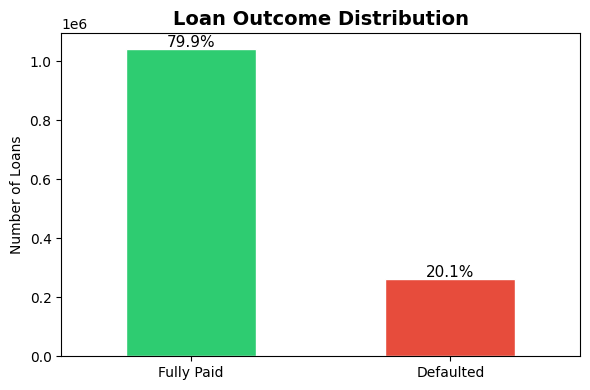


Note: The ~80/20 split means the model will naturally favour predicting 'Fully Paid'


In [20]:
# Loan amount distribution
# Establish the class imbalance upfront — this matters for interpreting model results

ax = df['loan_status'].value_counts().plot(
    kind='bar', figsize=(6, 4), color=['#2ecc71', '#e74c3c'], edgecolor='white'
)
plt.title("Loan Outcome Distribution", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Number of Loans")
plt.xticks(rotation=0)

# Annotate with percentages so the imbalance is immediately readable
total = len(df)
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + total * 0.005),
                ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("01_loan_status.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: The ~80/20 split means the model will naturally favour predicting 'Fully Paid'")


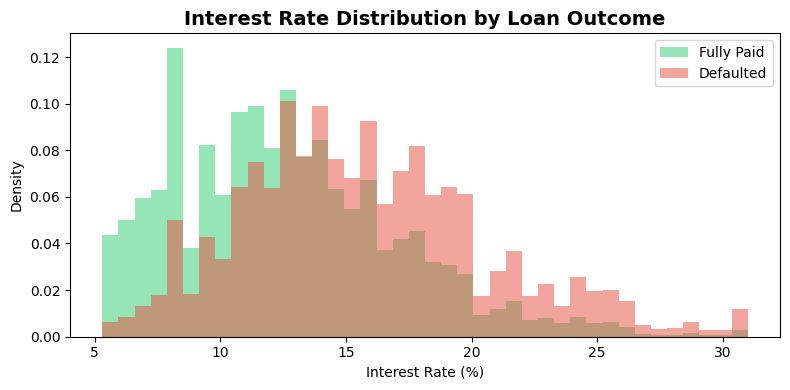

Median interest rate — Fully Paid: 12.3%  |  Defaulted: 15.1%
Defaulters paid on average 2.8pp more in interest


In [8]:
# Interest rate is one of the clearest separators between outcomes
plt.figure(figsize=(8, 4))
for status, colour in zip(['Fully Paid', 'Defaulted'], ['#2ecc71', '#e74c3c']):
    subset = df[df['loan_status'] == status]['int_rate']
    plt.hist(subset, bins=40, alpha=0.5, label=status, color=colour, density=True)

plt.title("Interest Rate Distribution by Loan Outcome", fontsize=14, fontweight='bold')
plt.xlabel("Interest Rate (%)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("02_interest_rate.png", dpi=150, bbox_inches='tight')
plt.show()

# Print the median difference — gives a concrete number for your narrative
paid_med = df[df['loan_status'] == 'Fully Paid']['int_rate'].median()
def_med  = df[df['loan_status'] == 'Defaulted']['int_rate'].median()
print(f"Median interest rate — Fully Paid: {paid_med:.1f}%  |  Defaulted: {def_med:.1f}%")
print(f"Defaulters paid on average {def_med - paid_med:.1f}pp more in interest")

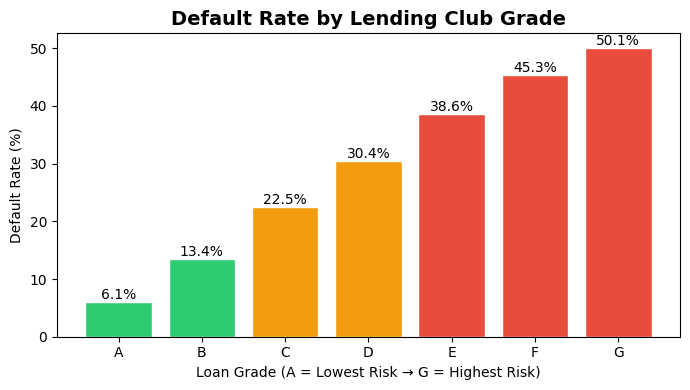

In [9]:
# Grade is Lending Club's own risk rating — A (safest) to G (riskiest)
# Calculate DEFAULT RATE per grade, not raw counts, so grades with fewer loans are comparable
grade_stats = (
    df.groupby('grade')['loan_status']
    .apply(lambda x: (x == 'Defaulted').mean() * 100)
    .reset_index()
    .rename(columns={'loan_status': 'default_rate'})
    .sort_values('grade')
)

plt.figure(figsize=(7, 4))
bars = plt.bar(grade_stats['grade'], grade_stats['default_rate'],
               color=['#2ecc71' if r < 20 else '#f39c12' if r < 35 else '#e74c3c'
                      for r in grade_stats['default_rate']],
               edgecolor='white')

for bar, val in zip(bars, grade_stats['default_rate']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10)

plt.title("Default Rate by Lending Club Grade", fontsize=14, fontweight='bold')
plt.xlabel("Loan Grade (A = Lowest Risk → G = Highest Risk)")
plt.ylabel("Default Rate (%)")
plt.tight_layout()
plt.savefig("03_grade_default_rate.png", dpi=150, bbox_inches='tight')
plt.show()

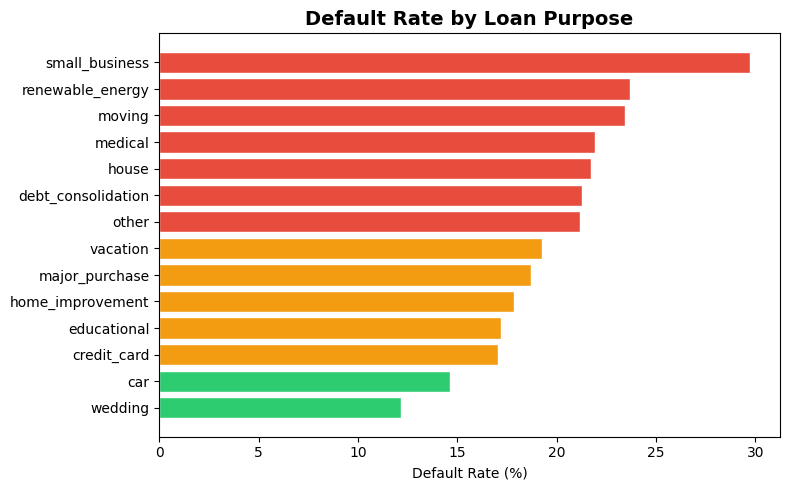

In [10]:
# Show which borrowing reasons carry the most default risk
purpose_stats = (
    df.groupby('purpose')['loan_status']
    .apply(lambda x: (x == 'Defaulted').mean() * 100)
    .reset_index()
    .rename(columns={'loan_status': 'default_rate'})
    .sort_values('default_rate', ascending=True)
)

plt.figure(figsize=(8, 5))
colours = ['#e74c3c' if r > 20 else '#f39c12' if r > 15 else '#2ecc71'
           for r in purpose_stats['default_rate']]
plt.barh(purpose_stats['purpose'], purpose_stats['default_rate'],
         color=colours, edgecolor='white')

plt.title("Default Rate by Loan Purpose", fontsize=14, fontweight='bold')
plt.xlabel("Default Rate (%)")
plt.tight_layout()
plt.savefig("04_purpose_default_rate.png", dpi=150, bbox_inches='tight')
plt.show()

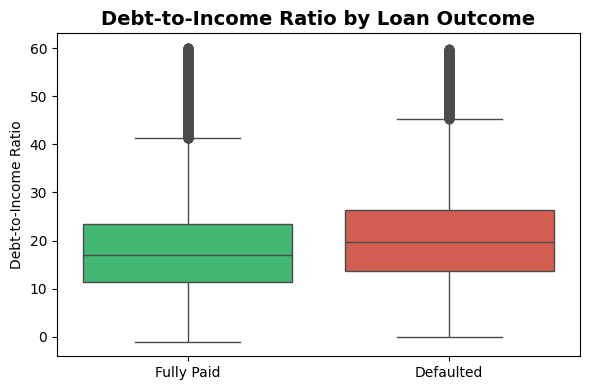

Median DTI — Fully Paid: 17.1  |  Defaulted: 19.8


In [11]:
# DTI - loan outcome
# Cap at 60 to remove extreme outliers that compress the plot
plt.figure(figsize=(6, 4))
sns.boxplot(
    x='loan_status', y='dti',
    data=df[df['dti'] <= 60],
    hue='loan_status',
    palette={'Fully Paid': '#2ecc71', 'Defaulted': '#e74c3c'},
    legend=False
)
plt.title("Debt-to-Income Ratio by Loan Outcome", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Debt-to-Income Ratio")
plt.tight_layout()
plt.savefig("05_dti_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

paid_dti = df[df['loan_status'] == 'Fully Paid']['dti'].median()
def_dti  = df[df['loan_status'] == 'Defaulted']['dti'].median()
print(f"Median DTI — Fully Paid: {paid_dti:.1f}  |  Defaulted: {def_dti:.1f}")

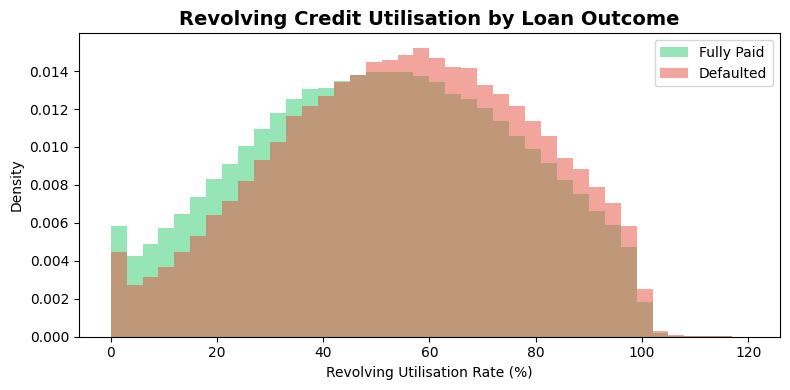

In [12]:
# How much of available credit someone is using — high utilisation = financial stress
plt.figure(figsize=(8, 4))
for status, colour in zip(['Fully Paid', 'Defaulted'], ['#2ecc71', '#e74c3c']):
    subset = df[(df['loan_status'] == status) & (df['revol_util'] <= 120)]['revol_util']
    plt.hist(subset, bins=40, alpha=0.5, label=status, color=colour, density=True)

plt.title("Revolving Credit Utilisation by Loan Outcome", fontsize=14, fontweight='bold')
plt.xlabel("Revolving Utilisation Rate (%)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("06_revol_util.png", dpi=150, bbox_inches='tight')
plt.show()

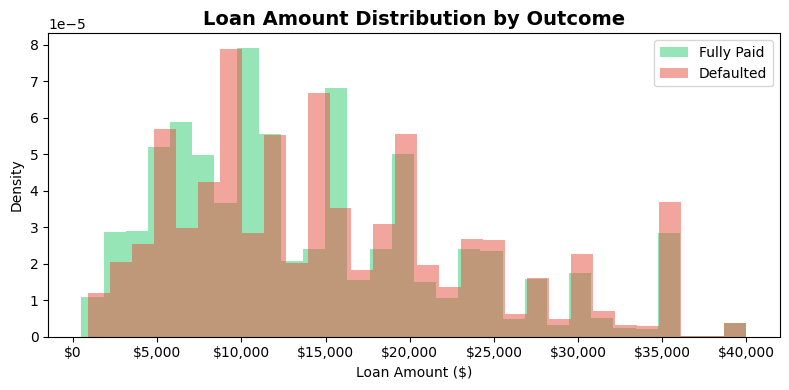

In [13]:
# Loan Amount Distribution

plt.figure(figsize=(8, 4))
for status, colour in zip(['Fully Paid', 'Defaulted'], ['#2ecc71', '#e74c3c']):
    subset = df[df['loan_status'] == status]['loan_amnt']
    plt.hist(subset, bins=30, alpha=0.5, label=status, color=colour, density=True)

plt.title("Loan Amount Distribution by Outcome", fontsize=14, fontweight='bold')
plt.xlabel("Loan Amount ($)")
plt.ylabel("Density")
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.savefig("07_loan_amount.png", dpi=150, bbox_inches='tight')
plt.show()

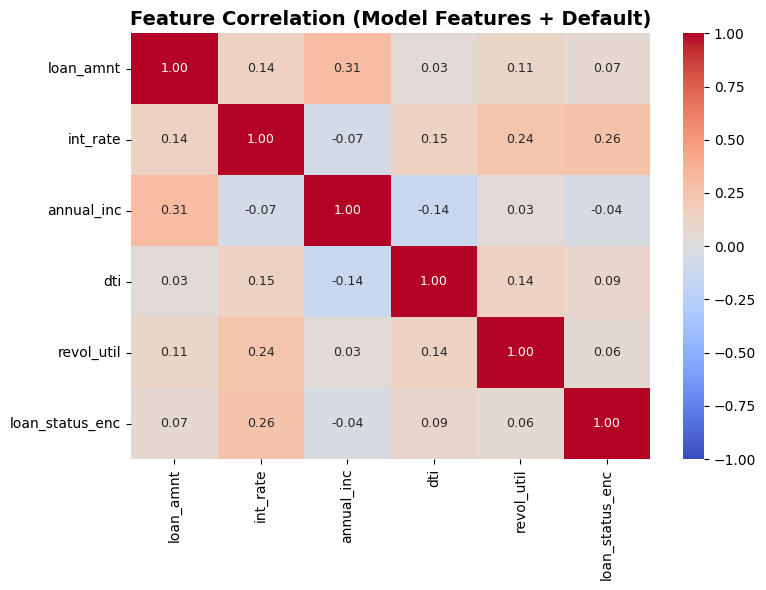

In [14]:
#Feature Correlation Heat Map

model_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'emp_length']
df_corr = df.copy()

# Temporarily encode loan_status for correlation
df_corr['loan_status_enc'] = (df_corr['loan_status'] == 'Defaulted').astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_corr[model_cols + ['loan_status_enc']].corr(numeric_only=True),
    cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1,
    annot_kws={'size': 9}
)
plt.title("Feature Correlation (Model Features + Default)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("08_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
#Data Cleaning and Preprocessing

df_clean = df.copy()

# Features — now includes int_rate and revol_util based on EDA findings
features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'emp_length']

# Show missing values only for relevant columns
display(df_clean[features + ['loan_status']].isnull().sum().rename("Missing Values"))

# Drop nulls only in the columns we use
df_clean = df_clean.dropna(subset=features + ['loan_status'])

# Encode target: 1 = Defaulted, 0 = Fully Paid
df_clean['loan_status'] = (df_clean['loan_status'] == 'Defaulted').astype(int)

# Clean emp_length
df_clean['emp_length'] = (
    df_clean['emp_length']
    .str.strip()
    .str.replace(r'\+ years| years| year|< ', '', regex=True)
    .str.strip()
    .replace('n/a', np.nan)
    .astype(float)
)
df_clean = df_clean.dropna(subset=['emp_length'])

# Filter outliers from training pool only (keeps test realistic)
# These thresholds match the source analysis
df_model = df_clean[
    (df_clean['annual_inc']  <= 250000) &
    (df_clean['dti']         <= 50)     &
    (df_clean['revol_util']  <= 120)
].copy()

print(f"Rows after cleaning:          {len(df_clean):,}")
print(f"Rows after outlier filtering: {len(df_model):,}")
print(f"Overall default rate:         {df_model['loan_status'].mean()*100:.1f}%")
assert len(df_model) > 0, "DataFrame is empty — check cleaning steps above"

,Missing Values
loan_amnt,0
int_rate,0
annual_inc,0
dti,312
revol_util,810
emp_length,75454
loan_status,0


Rows after cleaning:          1,227,377
Rows after outlier filtering: 1,212,844
Overall default rate:         19.7%


In [16]:
#Train/Test Split & Scaling

X = df_model[features]
y = df_model['loan_status']

# Stratify ensures the 80/20 class split is preserved in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Default rate in train: {y_train.mean()*100:.1f}%")
print(f"Default rate in test:  {y_test.mean()*100:.1f}%")

Training set: 970,275 rows
Test set:     242,569 rows
Default rate in train: 19.7%
Default rate in test:  19.7%


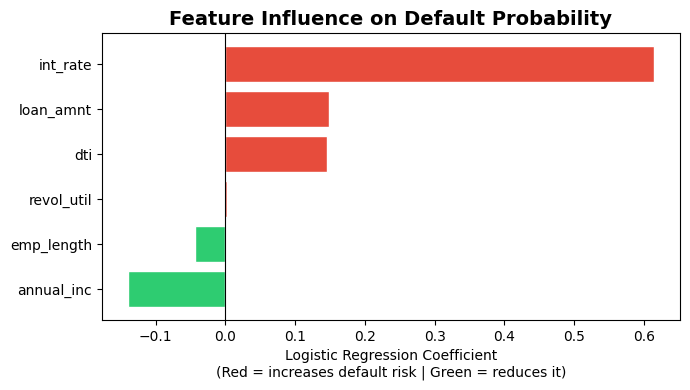

In [17]:
# Model Training
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Feature importance — shows which variables drive the model
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(7, 4))
colours = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colours, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Influence on Default Probability", fontsize=14, fontweight='bold')
plt.xlabel("Logistic Regression Coefficient\n(Red = increases default risk | Green = reduces it)")
plt.tight_layout()
plt.savefig("09_feature_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()


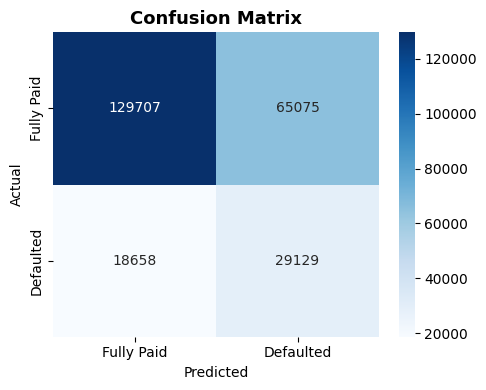

              precision    recall  f1-score   support

  Fully Paid       0.87      0.67      0.76    194782
   Defaulted       0.31      0.61      0.41     47787

    accuracy                           0.65    242569
   macro avg       0.59      0.64      0.58    242569
weighted avg       0.76      0.65      0.69    242569



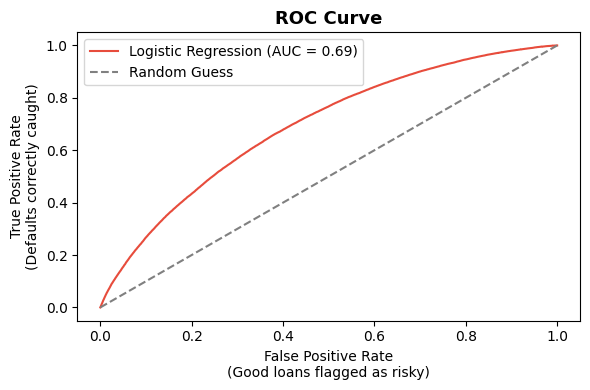

ROC-AUC Score: 0.6918


In [18]:
# Model Evaluation
# Confusion Matrix
plt.figure(figsize=(5, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fully Paid', 'Defaulted'],
            yticklabels=['Fully Paid', 'Defaulted'])
plt.title("Confusion Matrix", fontsize=13, fontweight='bold')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("10_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred,
      target_names=['Fully Paid', 'Defaulted']))

# ROC Curve
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='#e74c3c', label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], '--', color='grey', label='Random Guess')
plt.xlabel("False Positive Rate\n(Good loans flagged as risky)")
plt.ylabel("True Positive Rate\n(Defaults correctly caught)")
plt.title("ROC Curve", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("11_roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

True Negative: Correctly identified a good loan — model said "will repay" and they did. This is the large number because most loans are fully paid.

True Positive: Correctly caught a default — model said "will default" and they did. This is what a lender cares most about.

False Positive: Model wrongly flagged a good borrower as risky. Business consequence: a creditworthy person gets declined. This damages customer relationships and costs the lender revenue.

False Negative: Model missed a default — said "will repay" but they didn't. Business consequence: the lender approves a loan that loses money. This is the most costly error in lending.

The reason we use class_weight='balanced' in the model is specifically to reduce false negatives — without it, the model would just predict "Fully Paid" for almost everyone and still achieve 80% accuracy, which is statistically impressive but commercially useless.

Classification Report Printed below the matrix, it gives three metrics per class:

Precision — of all the loans the model predicted would default, what fraction actually did? Low precision means lots of false alarms.

Recall — of all the loans that actually defaulted, what fraction did the model catch? Low recall means lots of missed defaults. In lending, this is the metric you optimise for.

F1 Score — the harmonic mean of precision and recall. Useful as a single number when there's a tradeoff between the two.

In [19]:
#Business Impact

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
total           = len(y_test)
default_rate    = y_pred.mean() * 100
caught_rate     = tp / (tp + fn) * 100   # Of all actual defaults, how many did we catch
false_alarm     = fp / (fp + tn) * 100   # Of all good loans, how many did we wrongly flag

print("=" * 50)
print("        BUSINESS IMPACT SUMMARY")
print("=" * 50)
print(f"Loans evaluated:              {total:,}")
print(f"Predicted default rate:       {default_rate:.1f}%")
print(f"Defaults correctly caught:    {caught_rate:.1f}%  ({tp:,} loans)")
print(f"Good loans wrongly flagged:   {false_alarm:.1f}%  ({fp:,} loans)")
print(f"Missed defaults:              {fn:,} loans")
print("=" * 50)
print(f"\nInterpretation:")
print(f"  For every 100 actual defaults, the model catches ~{caught_rate:.0f}.")
print(f"  For every 100 good loans, ~{false_alarm:.0f} are incorrectly declined.")

        BUSINESS IMPACT SUMMARY
Loans evaluated:              242,569
Predicted default rate:       38.8%
Defaults correctly caught:    61.0%  (29,129 loans)
Good loans wrongly flagged:   33.4%  (65,075 loans)
Missed defaults:              18,658 loans

Interpretation:
  For every 100 actual defaults, the model catches ~61.
  For every 100 good loans, ~33 are incorrectly declined.
